# Preprocessing Northern Hemisphere Radio Maps (Fine Resolution)

## Overview

This notebook preprocesses radio continuum maps for synchrotron curvature analysis in the **Northern Hemisphere** at **fine angular resolution** (1.2 degree FWHM, $N_{\rm side}=256$).

### Scientific Context

Synchrotron radiation from cosmic-ray electrons spiraling in Galactic magnetic fields dominates the radio sky at low frequencies. Characterizing the synchrotron spectral energy distribution (SED) requires multi-frequency observations with consistent calibration and resolution.

### Input Data Sources

| Frequency Range (MHz) | Survey | Resolution | Reference |
|----------------------|--------|------------|-----------|
| 41.8-73.2 | OVRO-LWA | ~15-18 arcmin | [Eastwood et al. 2018](https://arxiv.org/abs/1711.00466) |
| 408 | Haslam reprocessed | 56 arcmin | [Remazeilles et al. 2015](https://arxiv.org/abs/1411.3628) |
| 1383-1712 | GMIMS-HBN | 40 arcmin | [Wolleben et al. 2021](https://iopscience.iop.org/article/10.3847/1538-3881/abf7c1) |

### Output Products

- **Maps**: HEALPix FITS file at $N_{\rm side}=256$, 1.2° FWHM resolution
- **Errors**: NPZ file containing per-frequency instrumental noise estimates

## 1. Dependencies and Utility Functions

### Required Libraries

- **healpy**: HEALPix map manipulation (spherical harmonics, smoothing, pixel operations)  
- **astropy**: Physical units, FITS I/O, and constants
- **scipy**: Orthogonal Distance Regression (ODR) for offset estimation
- **wget**: Downloading remote data files

In [1]:
import wget
import os
import healpy as hp
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.odr import Model, Data, ODR
from scipy.optimize import curve_fit
from astropy import units as u, constants as const
from astropy.io import fits


def b(nu):
    """
    Compute the CMB temperature derivative of blackbody intensity.
    
    Calculates dI/dT_CMB as defined in Eq. 8 of Planck 2013 IX.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency with units.
    
    Returns
    -------
    astropy.units.Quantity
        Derivative dI/dT_CMB in W/(m^2 K Hz).
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2 * const.h * nu ** 3 / const.c ** 2 / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    Compute the Rayleigh-Jeans temperature derivative of intensity.
    
    Calculates dI/dT_RJ as defined in Eq. 30 of Planck 2013 IX.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency with units.
    
    Returns
    -------
    astropy.units.Quantity
        Derivative dI/dT_RJ in W/(m^2 K Hz).
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def brightness2Tcmb(nu, bandpass=None):
    """
    Compute conversion factor from Jy/sr to K_CMB.
    
    Parameters
    ----------
    nu : astropy.units.Quantity or float
        Observation frequency (assumes GHz if unitless).
    bandpass : array-like, optional
        Bandpass transmission function for band-averaged conversion.
    
    Returns
    -------
    astropy.units.Quantity
        Conversion factor from intensity to CMB temperature.
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Compute conversion factor from Jy/sr to K_RJ.
    
    Parameters
    ----------
    nu : astropy.units.Quantity or float
        Observation frequency (assumes GHz if unitless).
    bandpass : array-like, optional
        Bandpass transmission function for band-averaged conversion.
    
    Returns
    -------
    astropy.units.Quantity
        Conversion factor from intensity to Rayleigh-Jeans temperature.
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert Rayleigh-Jeans (antenna) temperature to CMB thermodynamic temperature.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency.
    Trj : float, optional
        Input RJ temperature value (default: 1.0).
    bandpass : array-like, optional
        Bandpass transmission function.
    
    Returns
    -------
    float
        Temperature in K_CMB units.
    """
    return Trj / Kcmb2Krj(nu=nu, Tcmb=1, bandpass=bandpass)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    """
    Convert CMB thermodynamic temperature to Rayleigh-Jeans temperature.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency.
    Tcmb : float, optional
        Input CMB temperature value (default: 1.0).
    bandpass : array-like, optional
        Bandpass transmission function.
    
    Returns
    -------
    float
        Temperature in K_RJ units.
    """
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )


def planckcorr(freq_ghz):
    """
    Compute the Planck correction factor for CMB-to-RJ conversion.
    
    Parameters
    ----------
    freq_ghz : float
        Frequency in GHz.
    
    Returns
    -------
    float
        Correction factor to convert from K_CMB to K_RJ.
    """
    freq = freq_ghz * 1e9
    CST = {
        "kbolt": 1.3806488e-23, 
        "light": 2.99792458e8, 
        "plancks": 6.626e-34, 
        "cmb_temp": 2.725
    }
    factor = CST["plancks"] * freq / (CST["kbolt"] * CST["cmb_temp"])
    correction = (np.exp(factor) - 1.0) ** 2 / (factor ** 2 * np.exp(factor))
    return correction

### Processing Notes

This notebook applies the following preprocessing steps:
- **Resolution**: Maps are downgraded to $N_{\rm side}=256$ (pixel size ~13.7 arcmin)
- **Smoothing**: All maps convolved to 1.2° FWHM common beam

The native pixel resolution at $N_{\rm side}=256$ is sufficient for degree-scale analysis, avoiding unnecessary computational overhead from higher $N_{\rm side}$ values.

**Note**: Offset estimation for some GMIMS-HBN channels may be unreliable due to limited sky overlap with the 408 MHz reference.

In [2]:
folder_path = "../ovro_lwa_data"
Path(folder_path).mkdir(parents=True, exist_ok=True)

In [3]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress


def rotate_map(mapin, coord_in, coord_out):
    """
    Rotate a HEALPix map between coordinate systems.
    
    Parameters
    ----------
    mapin : array-like
        Input HEALPix map.
    coord_in : str
        Input coordinate system ('G' for Galactic, 'C' for Celestial, 'E' for Ecliptic).
    coord_out : str
        Output coordinate system.
    
    Returns
    -------
    array-like
        Rotated HEALPix map.
    """
    alm = hp.map2alm(mapin)
    R = hp.Rotator(coord=[coord_in, coord_out])
    alm = R.rotate_alm(alm)
    map_out = hp.alm2map(alm, nside=hp.get_nside(mapin))
    return map_out


def sform(param, xxx):
    """Linear model for ODR fitting: y = m*x + c."""
    return xxx * param[0] + param[1]


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """
    Compute spectral index between two frequencies using ODR.
    
    Parameters
    ----------
    xdat, ydat : array-like
        Temperature data at frequencies v1 and v2.
    xnoise, ynoise : array-like
        Uncertainties in xdat and ydat.
    v1, v2 : float
        Frequencies in MHz.
    
    Returns
    -------
    beta : float
        Spectral index.
    beta_error : float
        Uncertainty in spectral index.
    myoutput : scipy.odr.Output
        Full ODR output object.
    """
    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2 / v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)
    
    return beta, beta_error, myoutput


def fitting_beta_curvature(X, beta, cs):
    """Quadratic model for spectral curvature fitting: y = beta*X + cs*X^2."""
    return beta * X + cs * X * X


def sfunc(xxx, bval, cval):
    """Linear function for curve fitting: y = bval*x + cval."""
    return xxx * bval + cval


def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =~np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    super_nans = hp.ud_grade(nan1.astype('int'), nside_out=nside_superpix).astype('bool') 
    super_pixs = np.arange(super_nans.size ) [super_nans] 
     
    offsets = np.zeros_like(super_pixs  )*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)     
    nansize =0 

    for jj, ipix in enumerate(super_pixs ) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        

        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.75:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 

    offmap[super_pixs] = offsets
    avec = np.nanmedian( offsets ) *map.unit
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 

## 2. Load Input Maps

### OVRO-LWA Low-Frequency Maps (41-73 MHz)

The Owens Valley Radio Observatory Long Wavelength Array (OVRO-LWA) provides northern sky coverage at seven frequency channels from 41.8 to 73.2 MHz with resolution ~15-18 arcmin.

### 408 MHz Reference Map (Haslam)

The reprocessed 408 MHz map serves as the reference for offset estimation.

### GMIMS-HBN L-band Maps (1383-1712 MHz)

The Global Magneto-Ionic Medium Survey High-Band North (GMIMS-HBN) provides L-band coverage with 40 arcmin resolution. Selected channels avoid RFI-contaminated frequencies.

In [4]:
freqs=np.array([
    41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
    ]) 
maps={}
mapserr={}
offerr={}

cwd = Path.cwd() 
for j,fr in enumerate(freqs) :
    if fr == 41.76:
        fstring=(f"ovro_lwa_sky_map_41.760MHz.fits")
    elif fr == 67.92:
        fstring=(f"ovro_lwa_sky_map_67.920MHz.fits")
    else:
        fstring=(f"ovro_lwa_sky_map_{fr}MHz.fits")
    
    try : 
        print(f"reading {fstring} ")
        maps[fr],_=  hp.read_map(f"../ovro_lwa_data/{fstring}" ,h=True  )
    except FileNotFoundError: 
        filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/ovro/{fstring}", out ="../ovro_lwa_data")
        maps[fr]=  hp.read_map(f"../ovro_lwa_data/{fstring}"  )
    
    zeros = np.where(maps[fr] == 0.0)
    maps[fr][zeros] = np.nan 

    maps[fr]*=u.K
    mapserr[fr] = 0.05 # 5 per cent for LWA calibration 
    offerr[fr] = 0.0

fstring="haslam408_ds_Remazeilles2014.fits"

try :
    print(f"reading {fstring} ")

    maps[408],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", out ="../ovro_lwa_data")
    maps[408]=  hp.read_map(f"../lwa_data/{fstring}"  )


maps[408]= (maps[408]*u.K -8.9*u.K ).to(maps[41.760].unit)
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) /  maps[408].value # 10 per cent for 408 calibration plus the 1.3K offset error
offerr[408] = 0.0 # it has already been added to maperr


fstring="GMIMS-HBN_v1_gal_hpx_freq_I.fits"
try :
        
    print(f"reading {fstring} ")

    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fits" ) 
except FileNotFoundError: 
    filename = wget.download( f"https://www.canfar.net/storage/vault/file/AstroDataCitationDOI/CISTI.CANFAR/21.0003/data/release/{fstring}", out ="../lwa_data")
    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fitss" )

header = hdul[0].header
data = hdul[0].data

#horrible RFI - missing data patches before map = 90
maps[1383] = data[90, :]
maps[1383]= (maps[1383]*u.K   ).to(maps[41.760].unit) 
offerr[1383] = 0.0
mapserr[1383] = 0.08 

maps[1418] = data[120, :]
maps[1418]= (maps[1418]*u.K   ).to(maps[41.760].unit) 
offerr[1418] = 0.0
mapserr[1418] = 0.08 

maps[1456] = data[152, :]
maps[1456]= (maps[1456]*u.K   ).to(maps[41.760].unit) 
offerr[1456] = 0.0
mapserr[1456] = 0.08 

maps[1487] = data[180, :]
maps[1487]= (maps[1487]*u.K   ).to(maps[41.760].unit) 
offerr[1487] = 0.0
mapserr[1487] = 0.08 

maps[1499] = data[190, :]
maps[1499]= (maps[1499]*u.K   ).to(maps[41.760].unit) 
offerr[1499] = 0.0
mapserr[1499] = 0.08 

maps[1521] = data[209, :]
maps[1521]= (maps[1521]*u.K   ).to(maps[41.760].unit) 
offerr[1521] = 0.0
mapserr[1521] = 0.08

maps[1614] = data[285, :]
maps[1614]= (maps[1614]*u.K   ).to(maps[41.760].unit) 
offerr[1614] = 0.0
mapserr[1614] = 0.08 

maps[1625] = data[300, :]
maps[1625]= (maps[1625]*u.K   ).to(maps[41.760].unit) 
offerr[1625] = 0.0
mapserr[1625] = 0.08 

maps[1660] = data[330, :]
maps[1660]= (maps[1660]*u.K   ).to(maps[41.760].unit) 
offerr[1660] = 0.0
mapserr[1660] = 0.08 

maps[1700] = data[358, :]
maps[1700]= (maps[1700]*u.K   ).to(maps[41.760].unit) 
offerr[1700] = 0.0
mapserr[1700] = 0.08 

maps[1712] = data[368, :]
maps[1712]= (maps[1712]*u.K   ).to(maps[41.760].unit) 
offerr[1712] = 0.0
mapserr[1712] = 0.08 

nside=256
npix= hp.nside2npix(nside)

reading ovro_lwa_sky_map_41.760MHz.fits 
reading ovro_lwa_sky_map_46.992MHz.fits 
reading ovro_lwa_sky_map_52.224MHz.fits 
reading ovro_lwa_sky_map_57.456MHz.fits 
reading ovro_lwa_sky_map_62.688MHz.fits 
reading ovro_lwa_sky_map_67.920MHz.fits 
reading ovro_lwa_sky_map_73.152MHz.fits 
reading haslam408_ds_Remazeilles2014.fits 
reading GMIMS-HBN_v1_gal_hpx_freq_I.fits 


## 3. Smoothing to Common Resolution

All maps are smoothed to a common angular resolution of **1.2 degree FWHM** and downgraded to $N_{\rm side}=256$.

The smoothing kernel FWHM is computed as:
$$\theta_{\rm smooth} = \sqrt{\theta_{\rm target}^2 - \theta_{\rm native}^2}$$

In [5]:
freqs  =  np.array([  k for k in maps.keys()  ])  
nside=256 
fwhms = {41.760: 17.5 *u.arcmin , 
         46.992: 16.3*u.arcmin,
         52.224: 15.2*u.arcmin,
         57.456: 14.9*u.arcmin,
         62.688: 15.0*u.arcmin,
         67.920: 15.0*u.arcmin,
         73.152: 15.1*u.arcmin,
         408.: 56.*u.arcmin,
         1280: 40.*u.arcmin,
         1315: 40.*u.arcmin,
         1349: 40.*u.arcmin,
         1383: 40.*u.arcmin,
         1418: 40.*u.arcmin,
         1456: 40.*u.arcmin,
         1487: 40.*u.arcmin,
         1499: 40.*u.arcmin,
         1521: 40.*u.arcmin,
         1614: 40.*u.arcmin,
         1625: 40.*u.arcmin,
         1660: 40.*u.arcmin,
         1700: 40.*u.arcmin,
         1712: 40.*u.arcmin,
         } 

## smooth maps to 1.0 degrees
fwhmax = (1.0 *u.deg ).to(fwhms[41.760].unit) 
# downgrade them to nside=512
print("smoothing and downgrading maps ")
noise_factor={} 
for k  in freqs:
    nans= np.ma.masked_invalid(maps[k] ).mask
    maps[k] [nans] =hp.UNSEEN *maps[k].unit
    maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
    noise_factor[k] = np.sqrt(hp.nside2npix(hp.get_nside (maps[k ])) /hp.nside2npix( nside )  )

    if hp.get_nside(maps[k]) != nside  : 
        maps[k] = hp.ud_grade(maps[k].value , nside_out=nside)*maps[k].unit
    if k == 408:
      mapserr[k] = hp.smoothing(mapserr[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
      mapserr[k] = hp.ud_grade(mapserr[k].value , nside_out=nside )*maps[k].unit
    nans= np.ma.masked_equal(maps[k].value, hp.UNSEEN  ).mask
    maps[k][nans] = np.nan 

smoothing and downgrading maps 


## 4. Noise and Calibration Uncertainties

### Error Model

- **OVRO-LWA**: 0.8 Jy/beam instrumental noise, converted to K using beam solid angle
- **Haslam 408 MHz**: 0.1 K instrumental noise ([Remazeilles et al. 2015](https://arxiv.org/pdf/1411.3628))
- **GMIMS-HBN**: ~20 mK per channel ([Wolleben et al. 2021](https://iopscience.iop.org/article/10.3847/1538-3881/abf7c1))

In [6]:

from scipy import integrate

def beamsolidangle(fwhm):
    """
    Given a FWHM resolution `fwhm`,
    it computes the solid angle subtended by a Gaussian-axisymmetric beam
     in steradians by performing :

    .. math::
        \Delta \Omega = \int d \phi  d\theta  \sin(theta) \e^{-\theta^2/(2\sigma_b^2)}
    """

    sigma = (fwhm / 2 / np.sqrt(2 * np.log(2))).to(u.rad).value
    
    x = np.linspace(0, 4 * sigma, 2048)
    Gaussian = lambda theta: np.exp(-((theta / (np.sqrt(2) * sigma)) ** 2))
    integrand = lambda theta: 2 * np.pi * np.sin(theta) * Gaussian(theta)
    Solid_angle = (
        integrate.quad(integrand, 0, x.max(), limit=1000, epsrel=1.0e-5)[0] * u.sr
    )
    return Solid_angle
freqs=np.array([
    41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
    ]) 
errors ={} 

errors_ovro =0.8 ### Jy/beam
 

for f in freqs  : 

    errors [f] = (errors_ovro *u.Jy/beamsolidangle(fwhms[f])).to(u.K,equivalencies=u.brightness_temperature(f*u.MHz))

for f in fwhms.keys() : 
    if f >1000 : 
        errors [f] = (20  *u.mK).to(u.K ) # sect. 4 in https://iopscience.iop.org/article/10.3847/1538-3881/abf7c1/pdf  but table 5 states 20 mK  


errors[408]= 0.1 *u.K # searching r.m.s. in https://arxiv.org/pdf/1411.3628 sigma_destr = 0.1 K 

storerrors ={} 
for f in maps.keys() : 
    storerrors[str(f)] = errors[f].value #/noise_factor[f] 

np.savez(f"../ovro_lwa_data/fine_north_errors_dict.npz", **storerrors)



for k  in sorted(maps.keys())  : 
    print(f"At {k} MHz , map error is {storerrors[str(k)]} ") 

At 41.76 MHz , map error is 508.6871548081155 
At 46.992 MHz , map error is 463.04659177673943 
At 52.224 MHz , map error is 431.1419100592076 
At 57.456 MHz , map error is 370.68443505700003 
At 62.688 MHz , map error is 307.2531349373647 
At 67.92 MHz , map error is 261.73981848295114 
At 73.152 MHz , map error is 222.6595734547553 
At 408 MHz , map error is 0.1 
At 1383 MHz , map error is 0.02 
At 1418 MHz , map error is 0.02 
At 1456 MHz , map error is 0.02 
At 1487 MHz , map error is 0.02 
At 1499 MHz , map error is 0.02 
At 1521 MHz , map error is 0.02 
At 1614 MHz , map error is 0.02 
At 1625 MHz , map error is 0.02 
At 1660 MHz , map error is 0.02 
At 1700 MHz , map error is 0.02 
At 1712 MHz , map error is 0.02 


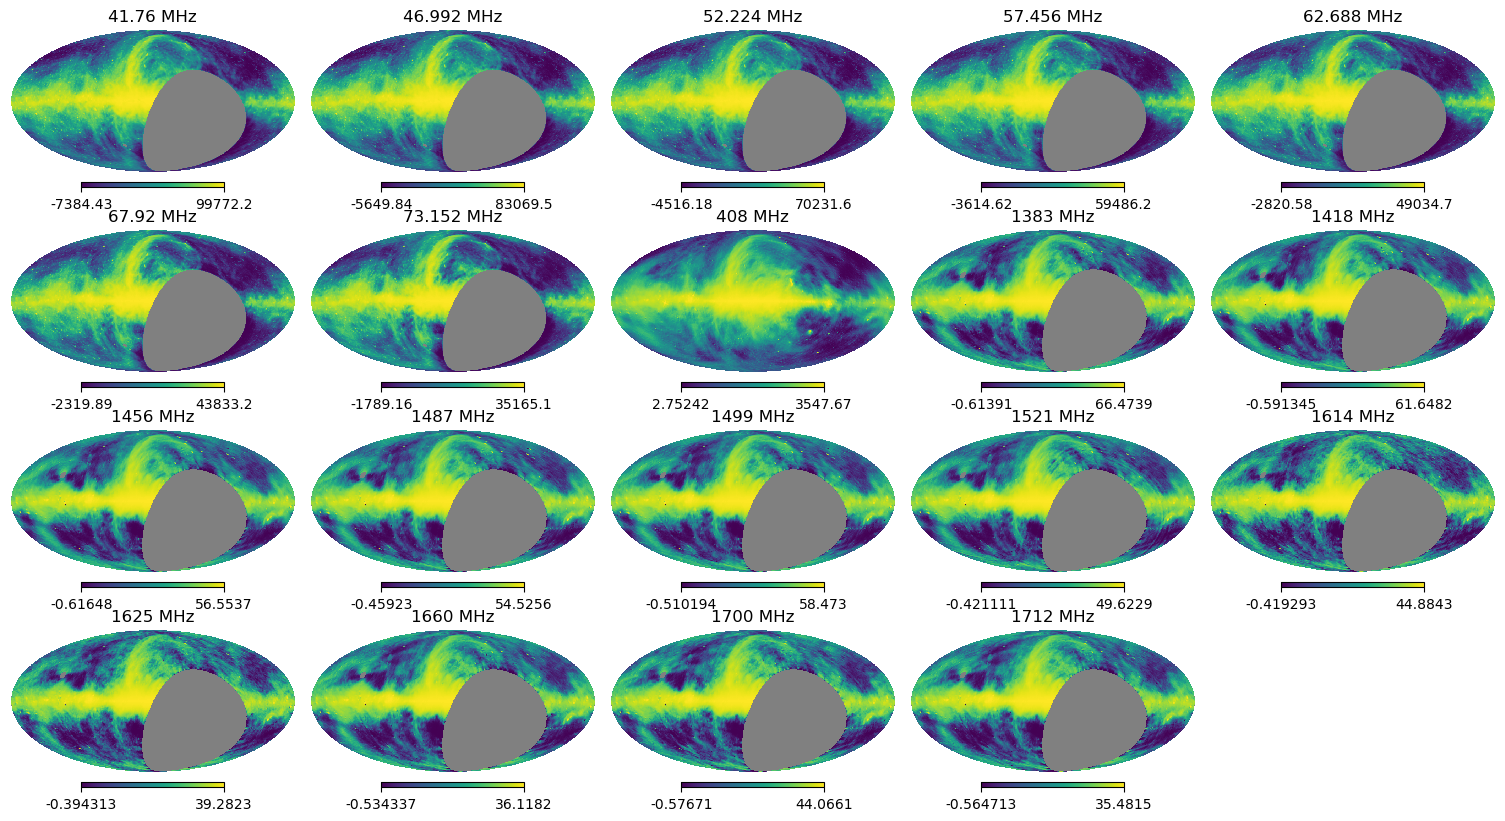

In [7]:
pl.figure(figsize=(15,10)) 

j=0
for fr,m in maps.items():
     
    hp.mollview( (m.value),  title=f'{fr} MHz'  , sub=(5,5,1+j) , notext=True ,norm='hist'   )
    
    j+=1

## 5. Zero-Level Offset Removal

### Methodology

We estimate and remove offsets by correlating each map with the 408 MHz reference using **Orthogonal Distance Regression** (ODR):

$$T(\nu) = a \cdot T_{408} + c$$

The intercept $c$ is estimated in coarse superpixels ($N_{\rm side}=8$), accepting only patches with correlation $r > 0.75$.

In [8]:
#read GMIMS offsets from coarse northern analysis 
file = open("../outputs/offset_coarse_north.txt")
oldk = []
c_off = []
c_err  = []

for line in file:
    values = line.strip().split()
    oldk.append(float(values[0]))
    c_off.append(float(values[1]))
    c_err.append(float(values[2]))

off11 = np.asarray(c_off)
err11 = np.asarray(c_err)
oldk = np.asarray(oldk)

def process_frequency(k):
    if k > 408:
        theval = np.where(oldk == k)[0][0]
        maps[k] = (maps[k].value - off11[theval])*u.K
        offsetvals[k] = off11[theval]*u.K
        offerr[k] = err11[theval]
        off_map[k] = np.zeros_like(maps[k]) + off11[theval]*u.K
    else:
        maps[k], offsetvals[k], offerr[k], off_map[k] = remove_off(maps[k], maps[408], mapserr[k], mapserr[408])
    return offsetvals[k], offerr[k], off_map[k]

offerr={}
off_map = {} 
offsetvals = {} 

for k in maps.keys():
    if k ==408 : continue
    offsetvals[k], offerr[k], off_map[k] = process_frequency(k)
    print(f" {k} MHz data estimated offset: {offsetvals[k]:.4f} ± {offerr[k]:.4f}")

 41.76 MHz data estimated offset: -7585.7550 K ± 193.8860
 46.992 MHz data estimated offset: -5455.5679 K ± 148.0693
 52.224 MHz data estimated offset: -4238.6128 K ± 114.7604
 57.456 MHz data estimated offset: -3154.6124 K ± 85.5916
 62.688 MHz data estimated offset: -2606.4006 K ± 69.4867
 67.92 MHz data estimated offset: -2067.4839 K ± 53.4632
 73.152 MHz data estimated offset: -1614.1779 K ± 40.8762
 1383 MHz data estimated offset: -0.3965 K ± 0.0196
 1418 MHz data estimated offset: -0.3298 K ± 0.0179
 1456 MHz data estimated offset: -0.3144 K ± 0.0151
 1487 MHz data estimated offset: -0.3203 K ± 0.0155
 1499 MHz data estimated offset: -0.3196 K ± 0.0154
 1521 MHz data estimated offset: -0.3398 K ± 0.0142
 1614 MHz data estimated offset: -0.2832 K ± 0.0125
 1625 MHz data estimated offset: -0.2422 K ± 0.0139
 1660 MHz data estimated offset: -0.2631 K ± 0.0126
 1700 MHz data estimated offset: -0.2263 K ± 0.0115
 1712 MHz data estimated offset: -0.2184 K ± 0.0118


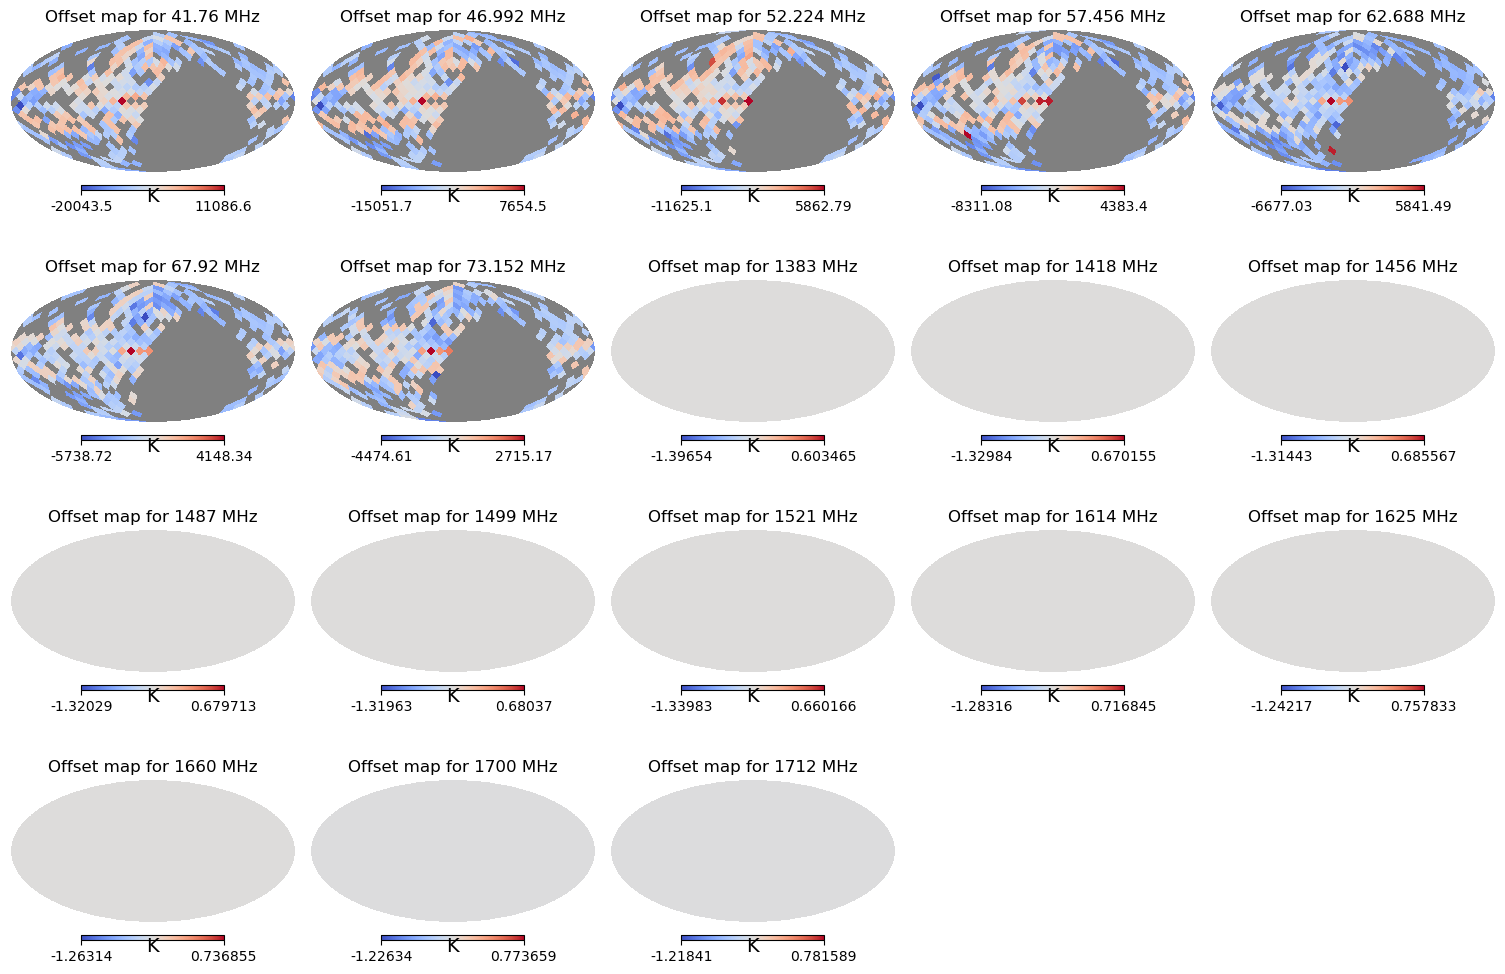

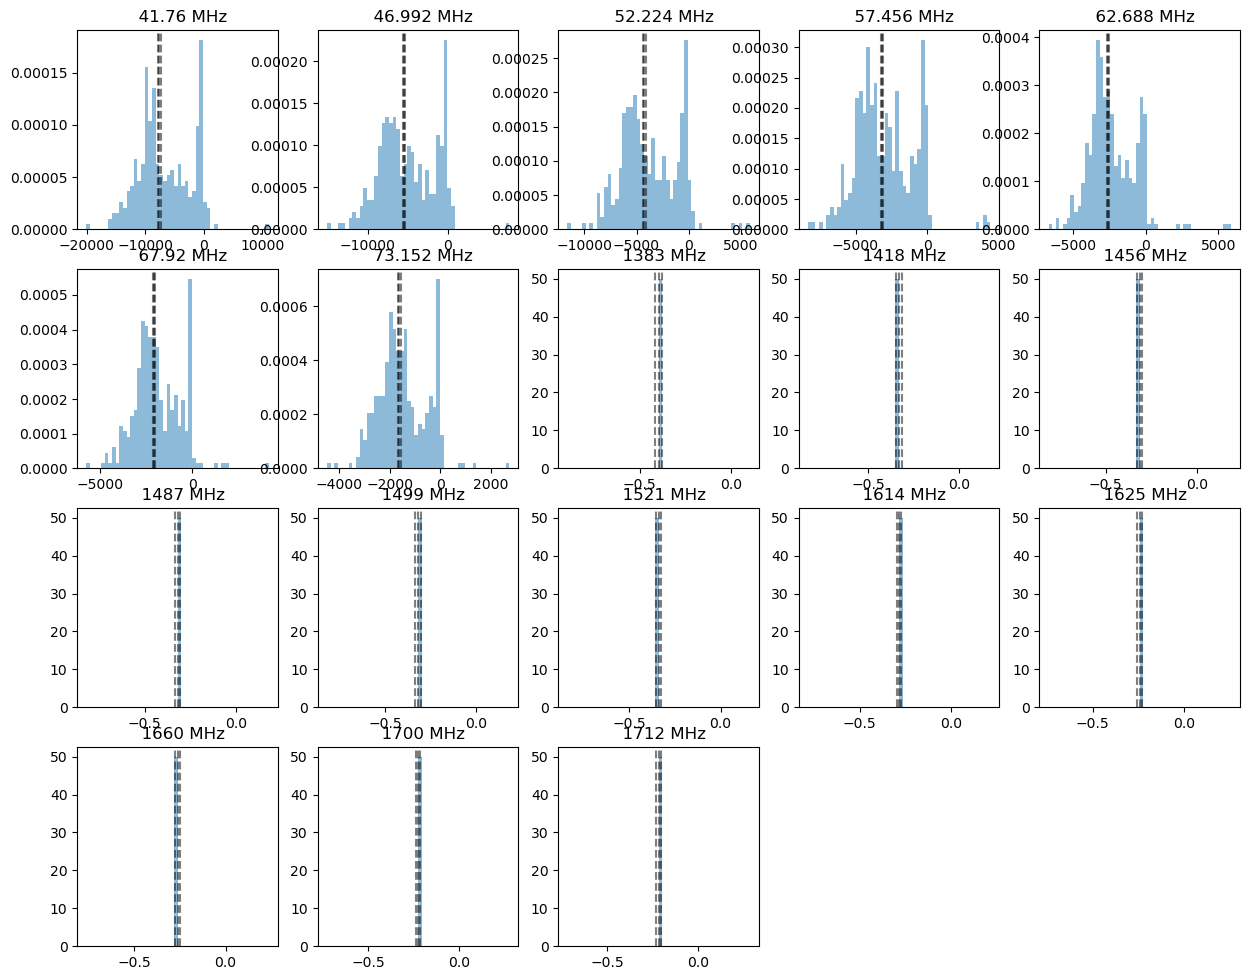

In [10]:
j=0
pl.figure(figsize=(15, 10))

for k in maps.keys():
    if k ==408 : continue
    hp.mollview(off_map[k] , title=f"Offset map for {k} MHz", unit=f"{maps[k].unit}" , cmap='coolwarm',
                sub=(4,5,j+1))
    j+=1
    
offset_file = open('../outputs/offset_fine_north.txt', 'w')

pl.figure(figsize=(15, 15))
j=0
for k, offset in offsetvals.items():
    error_offset = offerr[k] 
    offset_map = off_map[k] 

    offset_file.write("%f %f % f\n" %(k, offset.value, error_offset))
    pl.subplot(5, 5, j+1)
    pl.title(f"  {k} MHz") 
    pl.hist(np.ma.masked_invalid(offset_map ).data.flatten(), bins=50, label=f"{k} MHz", alpha=0.5, density=True)
    pl.axvline ( offset.value,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    j+=1

offset_file.close()

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_19746/2586610925.py:6: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,5,1+j) , notext=True ,  min=-1,  max=10 , unit = f'log({m.unit})'   , cmap='inferno')


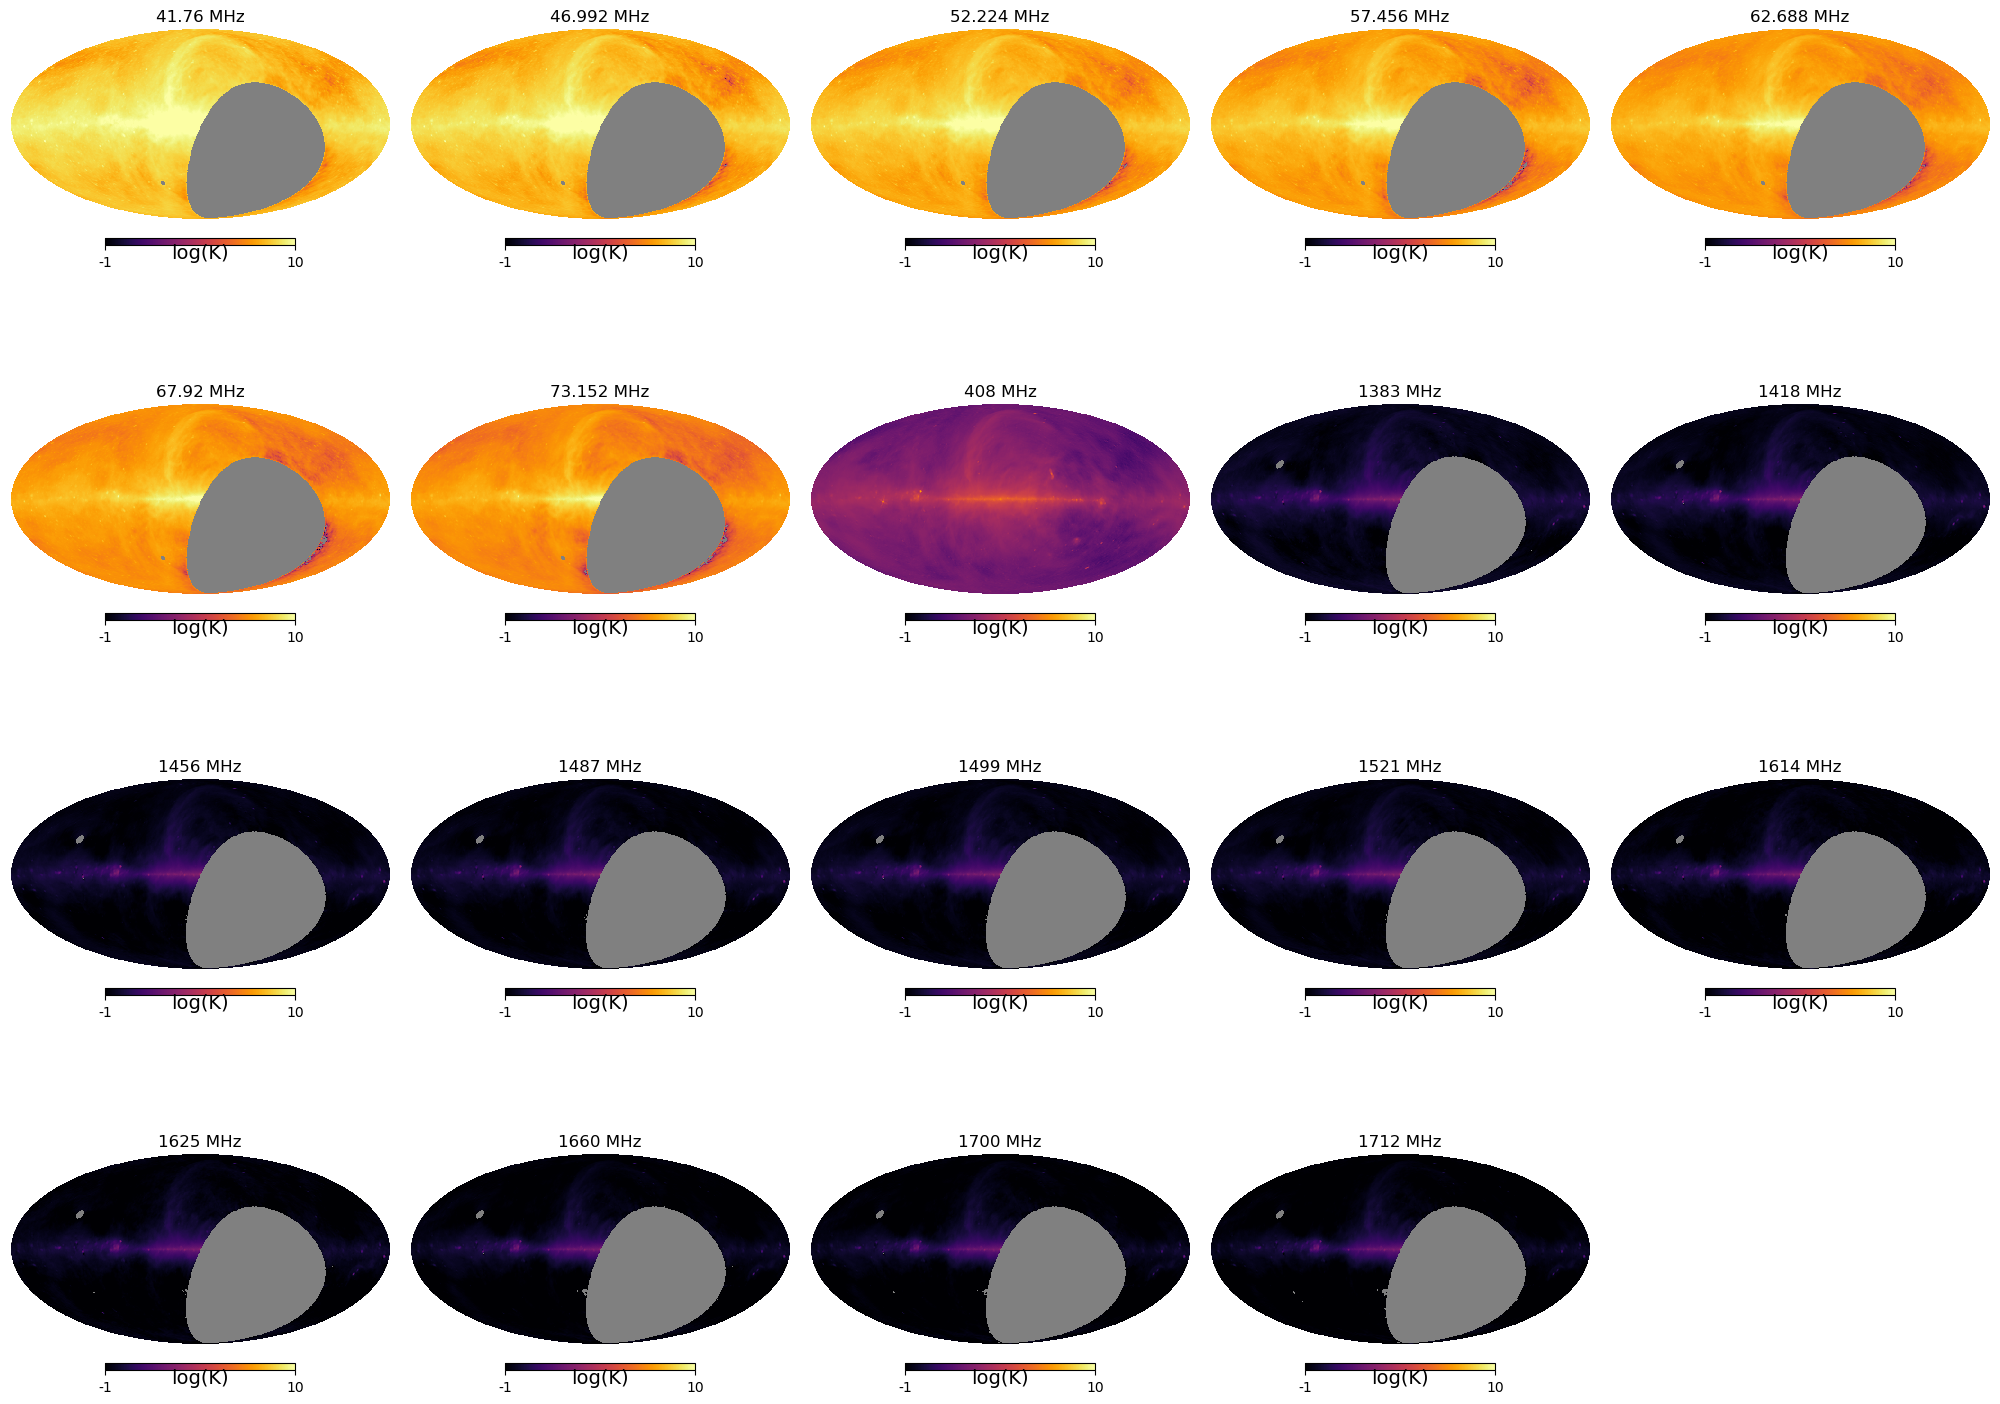

In [11]:
pl.figure(figsize=(20,15)) 

j=0
for fr,m in maps.items():
     
    hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,5,1+j) , notext=True ,  min=-1,  max=10 , unit = f'log({m.unit})'   , cmap='inferno')
    
    j+=1




In [12]:
from astropy.table import Table
t = Table([m for m in maps.values() ] , names=(m for m in maps.keys()))

t.write(f'../ovro_lwa_data/fine_north_maps_nside{nside}.fits', format='fits', overwrite=True )

---

## Summary

This notebook has preprocessed northern hemisphere radio maps for synchrotron spectral analysis:

**Outputs produced:**
- `fine_north_maps_nside256.fits` — Multi-frequency HEALPix maps at 1.2° resolution
- `fine_north_errors_dict.npz` — Per-frequency instrumental noise estimates

**Next steps:**
- Use these maps as input to the spectral fitting pipeline

## 6. Save Output Products

Export the preprocessed maps for downstream spectral analysis.